In [ ]:
!pip uninstall -y torchvision
!pip install -q \
torch \
torchvision==0.16.1 \
torchaudio \
transformers \
datasets \
accelerate \
evaluate \
sentencepiece \
scikit-learn

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision==0.16.1 (from versions: 0.17.0, 0.17.1, 0.17.2, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 0.20.0, 0.20.1, 0.21.0, 0.22.0, 0.22.1, 0.23.0, 0.24.0, 0.24.1, 0.25.0, 0.26.0, 0.27.0)
ERROR: No matching distribution found for torchvision==0.16.1


In [ ]:
import torch
import transformers
import datasets
import accelerate

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
Transformers: 5.0.0
Datasets: 4.8.5
Accelerate: 1.13.0
CUDA: True
Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base = "/content/drive/MyDrive/mental_health_predictor_v2"

for root, dirs, files in os.walk(base):
    for file in files:
        print(os.path.join(root, file))

/content/drive/MyDrive/mental_health_predictor_v2/both_train.csv
/content/drive/MyDrive/mental_health_predictor_v2/both_test.csv
/content/drive/MyDrive/mental_health_predictor_v2/sentiment-analysis-for-mental-health.csv
/content/drive/MyDrive/mental_health_predictor_v2/mental_disorders_reddit.csv
/content/drive/MyDrive/mental_health_predictor_v2/adhd.csv
/content/drive/MyDrive/mental_health_predictor_v2/ptsd.csv
/content/drive/MyDrive/mental_health_predictor_v2/ocd.csv
/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv
/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot1_label_distribution.png
/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot2_post_length.png
/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot3_wordcloud.png
/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot4_top_words.png
/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot5_avg_length.png
/content/drive/MyDrive/mental_health

In [ ]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns.tolist())

df.head()

(80000, 2)
['text', 'label']


,text,label
0,"now i don't mean less intelligent slower, i me...",adhd
1,Need structure in my life but feel claustropho...,adhd
2,How do I access if my adhd medication is worki...,adhd
3,Just got fired - Looking on advice (tldr at en...,adhd
4,Recently diagnosed- started on 5mg of Adderall...,adhd


In [ ]:
import pickle

LE_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model/label_encoder.pkl"

with open(LE_PATH, "rb") as f:
    le = pickle.load(f)

print(le.classes_)

['adhd' 'anxiety' 'bipolar' 'bpd' 'depression' 'normal' 'ocd' 'ptsd'
 'schizophrenia' 'suicidal']


In [ ]:
print(df.columns.tolist())

['text', 'label']


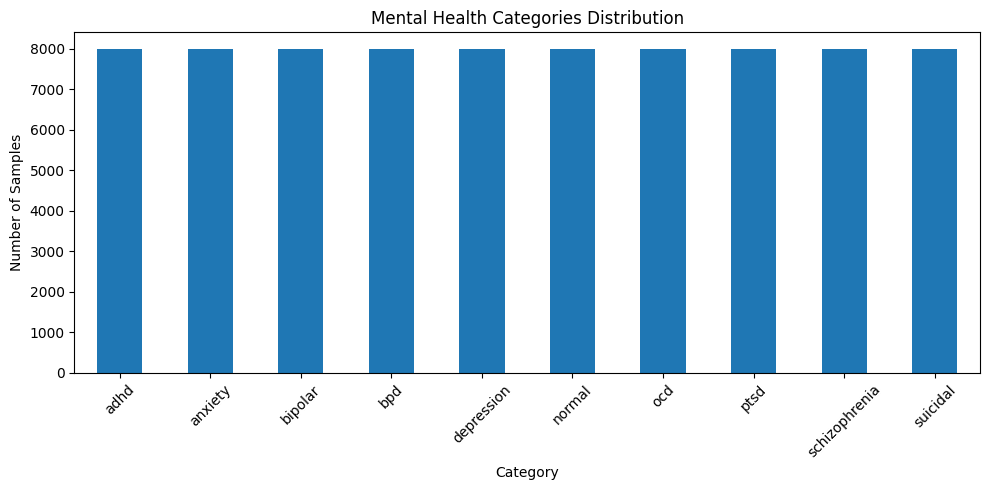

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv")

plt.figure(figsize=(10,5))
df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Mental Health Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot1_label_distribution.png")
plt.show()

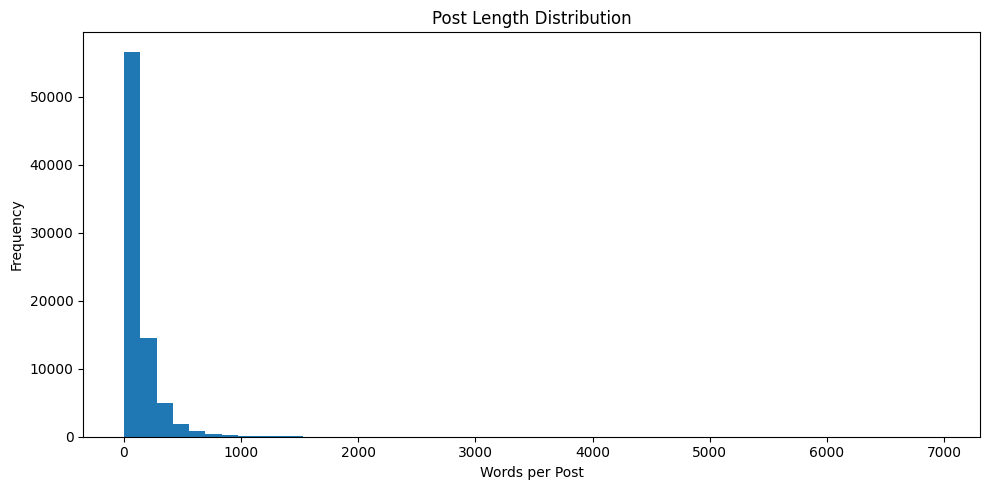

In [ ]:
df["text_length"] = df["text"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
plt.hist(df["text_length"], bins=50)
plt.title("Post Length Distribution")
plt.xlabel("Words per Post")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot2_post_length.png")
plt.show()

In [ ]:
!pip install wordcloud -q

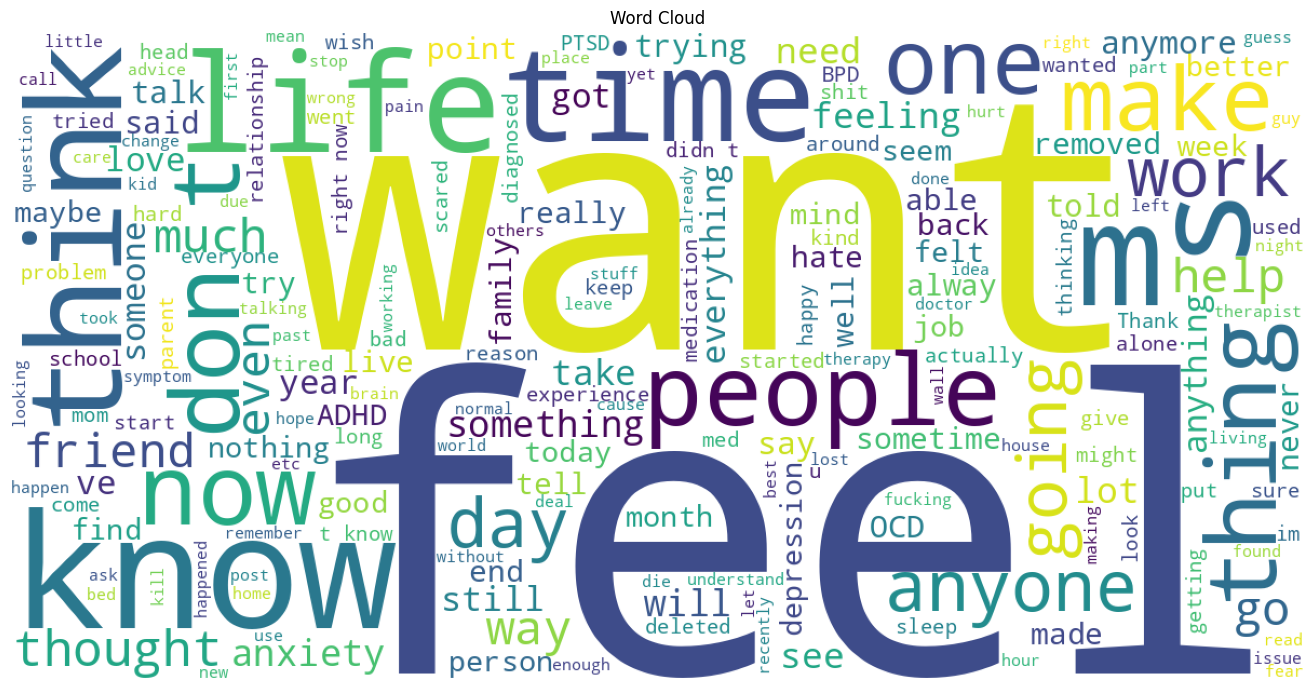

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["text"].astype(str))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot3_wordcloud.png")
plt.show()

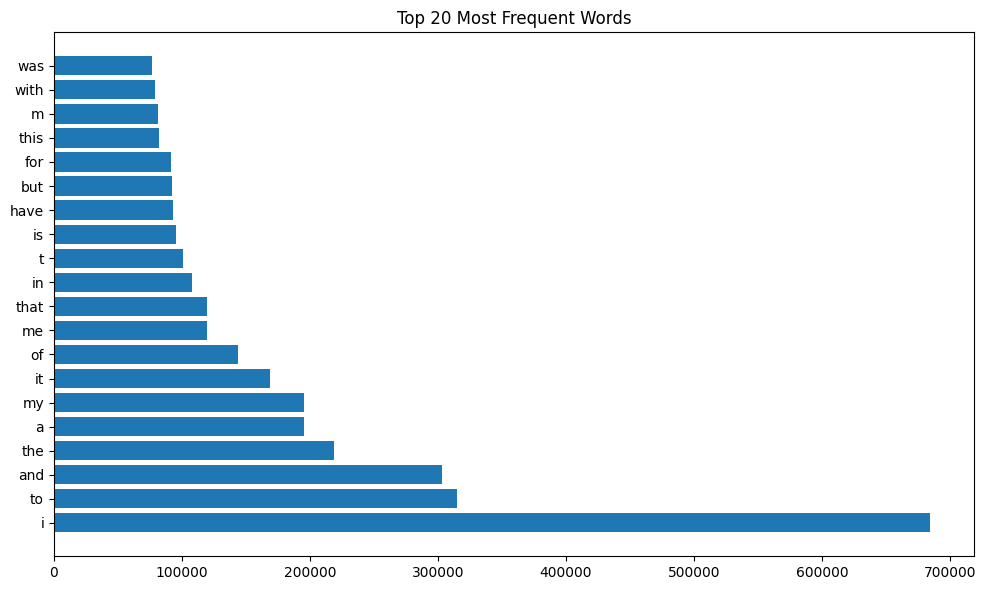

In [ ]:
from collections import Counter
import re

words = []

for txt in df["text"].astype(str):
    words.extend(re.findall(r"\b[a-zA-Z]+\b", txt.lower()))

top_words = Counter(words).most_common(20)

words_df = pd.DataFrame(top_words, columns=["word","count"])

plt.figure(figsize=(10,6))
plt.barh(words_df["word"], words_df["count"])
plt.title("Top 20 Most Frequent Words")
plt.tight_layout()

plt.savefig("/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot4_top_words.png")
plt.show()

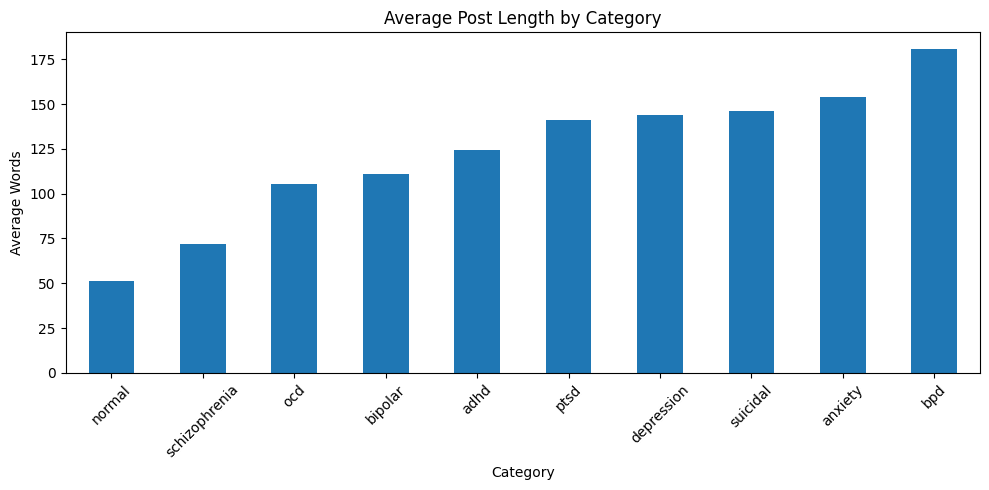

In [ ]:
avg_lengths = df.groupby("label")["text_length"].mean().sort_values()

plt.figure(figsize=(10,5))
avg_lengths.plot(kind="bar")
plt.title("Average Post Length by Category")
plt.xlabel("Category")
plt.ylabel("Average Words")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/mental_health_predictor_v2/outputs/plot5_avg_length.png")
plt.show()

In [ ]:
import pandas as pd
import pickle

DATA_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv"
LE_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model/label_encoder.pkl"

df = pd.read_csv(DATA_PATH)

with open(LE_PATH, "rb") as f:
    le = pickle.load(f)

print(df.shape)
print(le.classes_)

(80000, 2)
['adhd' 'anxiety' 'bipolar' 'bpd' 'depression' 'normal' 'ocd' 'ptsd'
 'schizophrenia' 'suicidal']


In [ ]:
df["encoded_label"] = le.transform(df["label"])

print(df.head())

                                                text label  encoded_label
0  now i don't mean less intelligent slower, i me...  adhd              0
1  Need structure in my life but feel claustropho...  adhd              0
2  How do I access if my adhd medication is worki...  adhd              0
3  Just got fired - Looking on advice (tldr at en...  adhd              0
4  Recently diagnosed- started on 5mg of Adderall...  adhd              0


In [ ]:
from sklearn.model_selection import train_test_split

X = df["text"].values
y = df["encoded_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 64000
Test : 16000


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded")

Tokenizer loaded


In [ ]:
from datasets import Dataset

train_ds = Dataset.from_dict({
    "text": X_train,
    "label": y_train
})

test_ds = Dataset.from_dict({
    "text": X_test,
    "label": y_test
})

print(train_ds)
print(test_ds)

Dataset({
    features: ['text', 'label'],
    num_rows: 64000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})


In [ ]:
MAX_LEN = 128

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

train_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print("Tokenization complete")

Map:   0%|          | 0/64000 [00:00<?, ? examples/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Tokenization complete


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=10
)

print(model.config.num_labels)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

10


In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
from transformers import TrainingArguments
help(TrainingArguments)

Help on class TrainingArguments in module transformers.training_args:

class TrainingArguments(builtins.object)
 |  TrainingArguments(output_dir: str | None = None, do_train: bool = False, do_eval: bool = False, do_predict: bool = False, eval_strategy: transformers.trainer_utils.IntervalStrategy | str = 'no', prediction_loss_only: bool = False, per_device_train_batch_size: int = 8, per_device_eval_batch_size: int = 8, gradient_accumulation_steps: int = 1, eval_accumulation_steps: int | None = None, eval_delay: float = 0, torch_empty_cache_steps: int | None = None, learning_rate: float = 5e-05, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, max_grad_norm: float = 1.0, num_train_epochs: float = 3.0, max_steps: int = -1, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_ratio: float | None = None, warmup_steps: float = 0, log_level: str = 'passive'

In [ ]:
import transformers
print(transformers.__version__)
print(transformers.__file__)

5.0.0
/usr/local/lib/python3.12/dist-packages/transformers/__init__.py


In [ ]:
from transformers import TrainingArguments
import inspect

print(inspect.signature(TrainingArguments.__init__))

(self, output_dir: str | None = None, do_train: bool = False, do_eval: bool = False, do_predict: bool = False, eval_strategy: transformers.trainer_utils.IntervalStrategy | str = 'no', prediction_loss_only: bool = False, per_device_train_batch_size: int = 8, per_device_eval_batch_size: int = 8, gradient_accumulation_steps: int = 1, eval_accumulation_steps: int | None = None, eval_delay: float = 0, torch_empty_cache_steps: int | None = None, learning_rate: float = 5e-05, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, max_grad_norm: float = 1.0, num_train_epochs: float = 3.0, max_steps: int = -1, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_ratio: float | None = None, warmup_steps: float = 0, log_level: str = 'passive', log_level_replica: str = 'warning', log_on_each_node: bool = True, logging_dir: str | None = None, logging_strategy: transfor

In [ ]:
import transformers
import torch

print("Transformers:", transformers.__version__)
print("Torch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))

Transformers: 5.0.0
Torch: 2.11.0+cu128
GPU: Tesla T4


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    logging_steps=100,

    save_total_limit=2,

    report_to="none",

    fp16=True
)

In [ ]:
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="weighted"
    )

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
trainer.train()

AttributeError: `AcceleratorState` object has no attribute `distributed_type`. This happens if `AcceleratorState._reset_state()` was called and an `Accelerator` or `PartialState` was not reinitialized.

In [ ]:
import torchvision
print(torchvision.__version__)

0.26.0+cu128


In [ ]:
from datasets import __version__
print(__version__)

4.0.0


In [ ]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import datasets
print(datasets.__version__)

4.8.5


In [ ]:
import torch
import transformers
import datasets

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA:", torch.cuda.is_available())

Torch: 2.11.0+cu128
Transformers: 5.0.0
Datasets: 4.8.5
CUDA: True


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=10
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    logging_steps=100,
    save_total_limit=2,

    report_to="none",
    fp16=True
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

NameError: name 'train_dataset' is not defined

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv"
)

print(df.shape)

(80000, 2)


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [ ]:
from transformers import AutoTokenizer

model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=256)

In [ ]:
import torch

class MentalHealthDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = MentalHealthDataset(train_encodings, list(train_labels))
val_dataset = MentalHealthDataset(val_encodings, list(val_labels))

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)
print(df["label"].head())

['adhd' 'anxiety' 'bipolar' 'bpd' 'depression' 'normal' 'ocd' 'ptsd'
 'schizophrenia' 'suicidal']
0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [ ]:
import torch

class MentalHealthDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        # Ensure labels are explicitly converted to a list of Python integers
        self.labels = [int(l) for l in labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Ensure labels are long tensors for classification
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [ ]:
train_dataset = MentalHealthDataset(train_encodings, train_labels.tolist())
val_dataset = MentalHealthDataset(val_encodings, val_labels.tolist())

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.733790,0.721112,0.762437,0.764161,0.762437,0.759919
2,0.606510,0.675802,0.780937,0.784287,0.780937,0.781093
3,0.453820,0.709986,0.784125,0.789663,0.784125,0.785232
4,0.313660,0.800568,0.782687,0.782640,0.782687,0.782457
5,0.220112,0.866856,0.780875,0.780505,0.780875,0.780484


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=20000, training_loss=0.5017065301895142, metrics={'train_runtime': 4550.876, 'train_samples_per_second': 70.316, 'train_steps_per_second': 4.395, 'total_flos': 4.210079268864e+16, 'train_loss': 0.5017065301895142, 'epoch': 5.0})

In [ ]:
trainer.save_model("/content/drive/MyDrive/mental_health_predictor_v2/model/bert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/mental_health_predictor_v2/model/bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/mental_health_predictor_v2/model/bert_model/tokenizer_config.json',
 '/content/drive/MyDrive/mental_health_predictor_v2/model/bert_model/tokenizer.json')

In [ ]:
trainer.evaluate()

{'eval_loss': 0.7113886475563049,
 'eval_accuracy': 0.7835,
 'eval_precision': 0.7887904393395668,
 'eval_recall': 0.7835,
 'eval_f1': 0.7845524534285915,
 'eval_runtime': 69.7896,
 'eval_samples_per_second': 229.261,
 'eval_steps_per_second': 14.329,
 'epoch': 5.0}

In [ ]:
import pandas as pd

PATH = "/content/drive/MyDrive/mental_health_predictor_v2"

test_df = pd.read_csv(f"{PATH}/both_test.csv")
test_df.head()

,ID,title,post,class_name,class_id
0,b07b978c-7760-4932-85cb-5797b5e74168,"basic needs for neurotypicals : food, clothing...",most people able to be productive and function...,adhd,0
1,b2868fd2-e885-400e-b780-446c9581b1f1,"""you're just an iphone in an android world.: d...",i'm 23f and recently quit my job as a features...,adhd,0
2,3191b3b1-d355-41b6-9588-caeb3e169c9b,"""what kind of music do you listen to?"" no answer",i just got finished with an interview and as t...,adhd,0
3,a3d60895-ef7c-4b57-b5be-632c9fd62150,couldn’t help crying while reading a post that...,off course i’ve forgotten what i exactly read....,adhd,0
4,66fae18e-e744-495f-b7a0-b985543f5052,shout-out to all the parents with adhd childre...,"i have six siblings, and at least 4 of us have...",adhd,0


In [ ]:
import pandas as pd

PATH = "/content/drive/MyDrive/mental_health_predictor_v2"

train_df = pd.read_csv(f"{PATH}/outputs/combined_balanced_dataset.csv")
test_df = pd.read_csv(f"{PATH}/both_test.csv")

train_df.head()

,text,label
0,"now i don't mean less intelligent slower, i me...",adhd
1,Need structure in my life but feel claustropho...,adhd
2,How do I access if my adhd medication is worki...,adhd
3,Just got fired - Looking on advice (tldr at en...,adhd
4,Recently diagnosed- started on 5mg of Adderall...,adhd


In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    return text

train_df["text"] = train_df["text"].apply(clean_text)
# The 'test_df' loaded from 'both_test.csv' has a 'post' column for text content.
# We apply clean_text to 'post' and create a new 'text' column in test_df for consistency.
test_df["text"] = test_df["post"].apply(clean_text)

In [ ]:
import pandas as pd
import pickle

# --- Code added to address NameError due to kernel restart and lost dependencies ---
PATH = "/content/drive/MyDrive/mental_health_predictor_v2"

# Reload train_df and test_df
train_df = pd.read_csv(f"{PATH}/outputs/combined_balanced_dataset.csv")
test_df = pd.read_csv(f"{PATH}/both_test.csv")

# Re-define and apply clean_text function (needed for test_df["text"])
def clean_text(text):
    text = str(text).lower()
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    return text

train_df["text"] = train_df["text"].apply(clean_text)
# Note: test_df from both_test.csv uses 'post' column for text content.
test_df["text"] = test_df["post"].apply(clean_text)

# Reload the pre-fitted 'le' object (needed for label encoding)
LE_PATH = f"{PATH}/model/label_encoder.pkl"
with open(LE_PATH, "rb") as f:
    le = pickle.load(f)

# Encode train_df["label"] (which contains string labels from the reloaded CSV)
train_df["label"] = le.transform(train_df["label"].astype(str))
# --- End of added code for self-containment ---

# Filter test_df to exclude labels not recognized by the pre-fitted 'le'.
# The 'y contains previously unseen labels: "none"' error indicated 'none' was not in le.classes_.
# We ensure only known labels are processed from test_df["class_name"].
valid_test_labels_mask = test_df["class_name"].isin(le.classes_)
test_df = test_df[valid_test_labels_mask].copy() # Update test_df to the filtered version

# Now, transform the labels of the filtered test_df from string ('class_name') to integer ('label').
test_df["label"] = le.transform(test_df["class_name"].astype(str))

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=256
    )

In [ ]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1240 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

In [ ]:
!pip install -q transformers==5.0.0 accelerate==1.13.0 datasets==4.8.5

In [ ]:
from accelerate.state import AcceleratorState
AcceleratorState._reset_state()

In [ ]:
import torch
import numpy as np
import pandas as pd
import pickle
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
PATH = "/content/drive/MyDrive/mental_health_predictor_v2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_df = pd.read_csv(f"{PATH}/outputs/combined_balanced_dataset.csv")
test_df = pd.read_csv(f"{PATH}/both_test.csv")

def clean_text(text):
    text = str(text).lower()
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    return text

train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["post"].apply(clean_text)

LE_PATH = f"{PATH}/model/label_encoder.pkl"
with open(LE_PATH, "rb") as f:
    le = pickle.load(f)

valid_test_labels_mask = test_df["class_name"].isin(le.classes_)
test_df = test_df[valid_test_labels_mask].copy()

train_df["label"] = le.transform(train_df["label"].astype(str))
test_df["label"] = le.transform(test_df["class_name"].astype(str))

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

MAX_LEN = 256

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=MAX_LEN
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(le.classes_)
)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    fp16=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

Map:   0%|          | 0/80000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1240 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import pickle
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [ ]:
DATA_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv"

MODEL_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model"

In [ ]:
df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(80000, 2)


,text,label
0,"now i don't mean less intelligent slower, i me...",adhd
1,Need structure in my life but feel claustropho...,adhd
2,How do I access if my adhd medication is worki...,adhd
3,Just got fired - Looking on advice (tldr at en...,adhd
4,Recently diagnosed- started on 5mg of Adderall...,adhd


In [ ]:
with open(f"{MODEL_PATH}/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

print(label_encoder.classes_)

['adhd' 'anxiety' 'bipolar' 'bpd' 'depression' 'normal' 'ocd' 'ptsd'
 'schizophrenia' 'suicidal']


In [ ]:
df["label"] = label_encoder.transform(df["label"])

df.head()

,text,label
0,"now i don't mean less intelligent slower, i me...",0
1,Need structure in my life but feel claustropho...,0
2,How do I access if my adhd medication is worki...,0
3,Just got fired - Looking on advice (tldr at en...,0
4,Recently diagnosed- started on 5mg of Adderall...,0


In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print(len(train_texts))
print(len(test_texts))

64000
16000


In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model"

for file in os.listdir(MODEL_PATH):
    print(file)

checkpoints
label_encoder.pkl
bert_model


In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model/bert_model"

for file in os.listdir(MODEL_PATH):
    print(file)

model.safetensors
config.json
tokenizer_config.json
training_args.bin
tokenizer.json


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT"
)

print("Tokenizer loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Tokenizer loaded


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/mental_health_predictor_v2/model/bert_model"
)

print("Model loaded")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model/bert_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [ ]:
from torch.utils.data import Dataset

class MentalHealthDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
test_dataset = MentalHealthDataset(
    test_encodings,
    test_labels.tolist()
)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
predictions = []

with torch.no_grad():

    for i in range(len(test_dataset)):

        item = test_dataset[i]

        input_ids = item["input_ids"].unsqueeze(0).to(device)

        attention_mask = item["attention_mask"].unsqueeze(0).to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pred = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()[0]

        predictions.append(pred)

KeyboardInterrupt: 

In [ ]:
acc = accuracy_score(
    test_labels,
    predictions
)

print("Accuracy:", acc)

Accuracy: 0.7836875


In [ ]:
print(
    classification_report(
        test_labels,
        predictions,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

         adhd       0.81      0.79      0.80      1600
      anxiety       0.81      0.76      0.78      1600
      bipolar       0.74      0.68      0.71      1600
          bpd       0.78      0.69      0.73      1600
   depression       0.58      0.73      0.65      1600
       normal       0.93      0.93      0.93      1600
          ocd       0.83      0.79      0.81      1600
         ptsd       0.79      0.76      0.77      1600
schizophrenia       0.73      0.76      0.75      1600
     suicidal       0.89      0.95      0.92      1600

     accuracy                           0.78     16000
    macro avg       0.79      0.78      0.78     16000
 weighted avg       0.79      0.78      0.78     16000



In [ ]:
cm = confusion_matrix(
    test_labels,
    predictions
)

print(cm)

[[1271   32   46   21   73    8   58   34   57    0]
 [  33 1215   32   47  154    4   46   35   24   10]
 [  54   36 1085   60  149   18   10   26  151   11]
 [  35   28   74 1104  213   11   22   61   41   11]
 [  38   38   51   80 1176   11   10   30   61  105]
 [  13   19   10    6   11 1481    2   17   24   17]
 [  38   57   22   23   45    6 1270  101   35    3]
 [  38   45   21   52   83   10   99 1210   31   11]
 [  46   29  125   20   93   24   16   23 1213   11]
 [   0    2    3    3   44   17    0    3   14 1514]]


In [ ]:
report = classification_report(
    test_labels,
    predictions,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "/content/drive/MyDrive/mental_health_predictor_v2/outputs/bioclinicalbert_results.csv"
)

print("Results Saved")

Results Saved


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv"
)

print(df.shape)

(80000, 2)


In [ ]:
import pickle

with open(
    "/content/drive/MyDrive/mental_health_predictor_v2/model/label_encoder.pkl",
    "rb"
) as f:
    label_encoder = pickle.load(f)

df["label"] = label_encoder.transform(df["label"])

print(label_encoder.classes_)

['adhd' 'anxiety' 'bipolar' 'bpd' 'depression' 'normal' 'ocd' 'ptsd'
 'schizophrenia' 'suicidal']


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print(len(train_texts))
print(len(test_texts))

64000
16000


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [ ]:
import torch
from torch.utils.data import Dataset

class MentalHealthDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = MentalHealthDataset(
    train_encodings,
    train_labels.tolist()
)

test_dataset = MentalHealthDataset(
    test_encodings,
    test_labels.tolist()
)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=10
)

print(model.config.num_labels)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


10


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./roberta_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    logging_steps=100,

    report_to="none"


)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

NameError: name 'trainer' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
print(torch.cuda.is_available())


False


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pickle

MODEL_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model/bert_model"

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully


In [ ]:
import torch
import pickle

with open(
    "/content/drive/MyDrive/mental_health_predictor_v2/model/label_encoder.pkl",
    "rb"
) as f:
    label_encoder = pickle.load(f)

text = "I feel hopeless and don't enjoy anything anymore"

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

with torch.no_grad():
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

print("Prediction:", label_encoder.inverse_transform([pred])[0])

Prediction: depression


In [ ]:
!pip install -q transformers datasets accelerate evaluate scikit-learn sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
import pandas as pd
import numpy as np
import torch
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

print("Torch:", torch.__version__)

Torch: 2.11.0+cu128


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv"
)

print(df.shape)
df.head()

(80000, 2)


,text,label
0,"now i don't mean less intelligent slower, i me...",adhd
1,Need structure in my life but feel claustropho...,adhd
2,How do I access if my adhd medication is worki...,adhd
3,Just got fired - Looking on advice (tldr at en...,adhd
4,Recently diagnosed- started on 5mg of Adderall...,adhd


In [ ]:
label_encoder = joblib.load(
    "/content/drive/MyDrive/mental_health_predictor_v2/model/label_encoder.pkl"
)

print(label_encoder.classes_)

['adhd' 'anxiety' 'bipolar' 'bpd' 'depression' 'normal' 'ocd' 'ptsd'
 'schizophrenia' 'suicidal']


In [ ]:
df["label"] = label_encoder.transform(df["label"])

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print(len(train_texts))
print(len(test_texts))

64000
16000


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model/bert_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

print("Model loaded")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded


In [ ]:
test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
class MentalHealthDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
test_dataset = MentalHealthDataset(
    test_encodings,
    test_labels
)

In [ ]:
def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./eval_results",
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics
)

In [ ]:
results = trainer.predict(test_dataset)

print(results.metrics)

{'test_loss': 0.7707870006561279, 'test_model_preparation_time': 0.0089, 'test_accuracy': 0.7669375, 'test_precision': 0.7722478255071649, 'test_recall': 0.7669375, 'test_f1': 0.7678284119248089, 'test_runtime': 120.1029, 'test_samples_per_second': 133.219, 'test_steps_per_second': 16.652}


In [ ]:
preds = np.argmax(results.predictions, axis=1)

print(
    classification_report(
        test_labels,
        preds,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

         adhd       0.80      0.77      0.78      1600
      anxiety       0.77      0.74      0.75      1600
      bipolar       0.72      0.67      0.69      1600
          bpd       0.77      0.66      0.71      1600
   depression       0.56      0.72      0.63      1600
       normal       0.90      0.93      0.91      1600
          ocd       0.82      0.78      0.80      1600
         ptsd       0.77      0.74      0.76      1600
schizophrenia       0.72      0.76      0.74      1600
     suicidal       0.89      0.92      0.91      1600

     accuracy                           0.77     16000
    macro avg       0.77      0.77      0.77     16000
 weighted avg       0.77      0.77      0.77     16000



In [ ]:
cm = confusion_matrix(
    test_labels,
    preds
)

cm

array([[1229,   41,   55,   28,   79,   15,   62,   34,   57,    0],
       [  39, 1180,   33,   49,  152,   19,   43,   47,   29,    9],
       [  58,   45, 1064,   54,  151,   21,   10,   27,  159,   11],
       [  34,   38,   79, 1049,  228,   17,   30,   67,   46,   12],
       [  38,   54,   50,   79, 1149,   20,   10,   38,   60,  102],
       [  16,   19,    9,    6,    9, 1481,    2,   17,   24,   17],
       [  38,   73,   24,   24,   43,    7, 1252,  100,   35,    4],
       [  41,   59,   26,   46,   85,   13,   97, 1190,   34,    9],
       [  49,   29,  126,   20,   89,   25,   17,   24, 1209,   12],
       [   2,    2,    3,    4,   65,   34,    1,    5,   16, 1468]])

In [ ]:
metrics_df = pd.DataFrame([results.metrics])

metrics_df.to_csv(
    "/content/drive/MyDrive/mental_health_predictor_v2/model/bioclinicalbert_results.csv",
    index=False
)

print("Results saved")

Results saved


In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model"

for file in os.listdir(MODEL_PATH):
    print(file)

checkpoints
label_encoder.pkl
bert_model
bioclinicalbert_results.csv


In [ ]:
import pandas as pd
import numpy as np
import torch
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
import pandas as pd
import numpy as np
import pickle
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [ ]:
DATA_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv"

MODEL_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/model"

In [ ]:
df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(80000, 2)


,text,label
0,"now i don't mean less intelligent slower, i me...",adhd
1,Need structure in my life but feel claustropho...,adhd
2,How do I access if my adhd medication is worki...,adhd
3,Just got fired - Looking on advice (tldr at en...,adhd
4,Recently diagnosed- started on 5mg of Adderall...,adhd


In [ ]:
with open(f"{MODEL_PATH}/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

print(label_encoder.classes_)

['adhd' 'anxiety' 'bipolar' 'bpd' 'depression' 'normal' 'ocd' 'ptsd'
 'schizophrenia' 'suicidal']


In [ ]:
df["label"] = label_encoder.transform(df["label"])

df.head()

,text,label
0,"now i don't mean less intelligent slower, i me...",0
1,Need structure in my life but feel claustropho...,0
2,How do I access if my adhd medication is worki...,0
3,Just got fired - Looking on advice (tldr at en...,0
4,Recently diagnosed- started on 5mg of Adderall...,0


In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print(len(train_texts))
print(len(test_texts))

64000
16000


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/mental_health_predictor_v2/outputs/combined_balanced_dataset.csv"
)

print(df.shape)

(80000, 2)


In [ ]:
import pickle

with open(
    "/content/drive/MyDrive/mental_health_predictor_v2/model/label_encoder.pkl",
    "rb"
) as f:
    label_encoder = pickle.load(f)

df["label"] = label_encoder.transform(df["label"])

print(label_encoder.classes_)

['adhd' 'anxiety' 'bipolar' 'bpd' 'depression' 'normal' 'ocd' 'ptsd'
 'schizophrenia' 'suicidal']


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print(len(train_texts))
print(len(test_texts))

64000
16000


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [ ]:
class MentalHealthDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            int(self.labels[idx]),
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = MentalHealthDataset(
    train_encodings,
    train_labels.tolist()
)

test_dataset = MentalHealthDataset(
    test_encodings,
    test_labels.tolist()
)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=10
)

print(model.config.num_labels)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


10


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./roberta_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    logging_steps=100,

    save_total_limit=2,

    report_to="none"
)

In [ ]:
print(train_labels[:10])

print(min(train_labels))
print(max(train_labels))

print(model.config.num_labels)

53834    6
10672    1
19711    2
69224    8
34394    4
71594    8
7258     0
17743    2
16348    2
1731     0
Name: label, dtype: int64
0
9
10


In [ ]:
print(model.config.num_labels)

print(min(train_dataset.labels))
print(max(train_dataset.labels))
print(set(train_dataset.labels))

10
0
9
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [ ]:
batch = train_dataset[0]

for k, v in batch.items():
    print(k, v.shape if hasattr(v, "shape") else v, v.dtype)

input_ids torch.Size([256]) torch.int64
attention_mask torch.Size([256]) torch.int64
labels torch.Size([]) torch.int64


In [ ]:
sample = train_dataset[0]

for k in sample:
    sample[k] = sample[k].unsqueeze(0)

with torch.no_grad():
    out = model(**sample)

print(out.logits.shape)

torch.Size([1, 10])


In [ ]:
batch = train_dataset[0]

for k, v in batch.items():
    print(k, v.shape if hasattr(v, "shape") else v, v.dtype)

input_ids torch.Size([256]) torch.int64
attention_mask torch.Size([256]) torch.int64
labels torch.Size([]) torch.int64


In [ ]:
print("Number of classes:", len(label_encoder.classes_))
print("Classes:", label_encoder.classes_)

Number of classes: 10
Classes: ['adhd' 'anxiety' 'bipolar' 'bpd' 'depression' 'normal' 'ocd' 'ptsd'
 'schizophrenia' 'suicidal']


In [ ]:
print(df["label"].min())
print(df["label"].max())
print(df["label"].nunique())

0
9
10


In [ ]:
print(model.config.num_labels)

10


In [ ]:
sample = train_dataset[0]

print(sample["labels"])
print(sample["labels"].dtype)

tensor(6)
torch.int64


In [ ]:
training_args = TrainingArguments(
    output_dir="./roberta_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    fp16=False
)

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.681566,0.660493,0.783813,0.784372,0.783813,0.781556


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.681566,0.660493,0.783813,0.784372,0.783813,0.781556
2,0.591096,0.634473,0.795562,0.800939,0.795562,0.796265
3,0.422662,0.648588,0.803000,0.803660,0.803000,0.802787
4,0.348000,0.706225,0.802500,0.802350,0.802500,0.802080
5,0.271731,0.755826,0.802562,0.801892,0.802562,0.802065


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=20000, training_loss=0.4946467785835266, metrics={'train_runtime': 14548.1422, 'train_samples_per_second': 21.996, 'train_steps_per_second': 1.375, 'total_flos': 4.210079268864e+16, 'train_loss': 0.4946467785835266, 'epoch': 5.0})

In [ ]:
preds = trainer.predict(test_dataset)

print(preds.metrics)

{'test_loss': 0.6341783404350281, 'test_accuracy': 0.796125, 'test_precision': 0.8013604100292685, 'test_recall': 0.796125, 'test_f1': 0.7967611856344077, 'test_runtime': 206.5916, 'test_samples_per_second': 77.448, 'test_steps_per_second': 4.84}


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = np.argmax(preds.predictions, axis=1)

print(
    classification_report(
        test_labels,
        y_pred,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

         adhd       0.82      0.83      0.82      1600
      anxiety       0.84      0.77      0.81      1600
      bipolar       0.76      0.67      0.71      1600
          bpd       0.81      0.70      0.75      1600
   depression       0.61      0.74      0.67      1600
       normal       0.98      0.88      0.93      1600
          ocd       0.77      0.85      0.81      1600
         ptsd       0.79      0.79      0.79      1600
schizophrenia       0.75      0.78      0.76      1600
     suicidal       0.88      0.95      0.92      1600

     accuracy                           0.80     16000
    macro avg       0.80      0.80      0.80     16000
 weighted avg       0.80      0.80      0.80     16000



In [ ]:
SAVE_PATH = "/content/drive/MyDrive/mental_health_predictor_v2/roberta_model"

model.save_pretrained(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

with open(
    f"{SAVE_PATH}/label_encoder.pkl",
    "wb"
) as f:
    pickle.dump(label_encoder,f)

print("RoBERTa saved successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RoBERTa saved successfully
